# Corners on Euro 2024 — Data Exploration

**Notebook 1 of the first analysis.** End state: you understand what the StatsBomb open data and 360 freeze frames look like for corner-resulting headed shots in Euro 2024.

**What this notebook is not:** it is not the analysis. It is not where you decide what the defensive structure features are. It is not where you build the `football_analytics/` package. Resist all three urges. If you find yourself extracting reusable functions, stop and put a TODO comment instead — the refactor happens in notebook 2.

**Stop condition for this notebook.** You can answer all of these from memory by the end:

1. How many corners are in Euro 2024 in the open data?
2. How many of those produce shots? How many of those shots are headers?
3. What does a 360 freeze frame at the moment of a corner-resulting headed shot actually look like as a data structure?
4. What is the field of view limitation in 360 data, and how often does it matter for corner shot situations?
5. What's the conversion rate of corner-resulting headed shots vs the StatsBomb xG estimate for those same shots?

If you cannot answer all five by the end of this notebook, you have not finished the notebook. If you can answer them after two days, you have finished it and you should move on regardless of whether the notebook "feels" complete.

## Setup

In [77]:
# Standard imports for this project.
# statsbombpy is the main loader. mplsoccer handles pitch visuals.
# pandas + numpy for the obvious reasons.
#
# Tip: if you haven't already, `uv add statsbombpy mplsoccer pandas numpy matplotlib`
# and `uv add --dev nbstripout` then `nbstripout --install` in the repo root
# so notebook diffs stay clean.

# imports go here
from statsbombpy import sb
from mplsoccer import Pitch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# HELPER FUNCTIONS

def load_frames(match_id):
    url = f"https://raw.githubusercontent.com/statsbomb/open-data/master/data/three-sixty/{match_id}.json"
    raw = requests.get(url).json()
    
    rows = []
    for frame in raw:
        event_uuid = frame['event_uuid']
        visible_area = frame['visible_area']
        for player in frame['freeze_frame']:
            rows.append({
                'event_uuid': event_uuid,
                'visible_area': visible_area,
                'location': player['location'],
                'teammate': player['teammate'],
                'actor': player['actor'],
                'keeper': player['keeper'],
            })
    return pd.DataFrame(rows)



## 1. Find Euro 2024 in the StatsBomb competitions table

The first thing to verify: Euro 2024 is actually in the open data and you have the competition_id / season_id pair. Don't skip this. The IDs are not stable across releases and hardcoding the wrong pair will silently give you a different tournament.

In [78]:
# Hint: statsbombpy.sb.competitions() returns a DataFrame of all available competitions.
# Filter to the row where competition_name contains "UEFA Euro" and season_name is "2024".
# Pull out competition_id and season_id and store them in named variables you'll reuse.
#
# Sanity check: print the row. Confirm match_available_360 is True for this competition.
# If it isn't, the rest of the notebook is impossible and you need to stop and figure out why.

comps = sb.competitions()
euro_comp = comps[
    (comps['competition_name'].str.contains('UEFA Euro'))
    & (comps['season_name'] == '2024')
]

comp_id = euro_comp['competition_id'].values[0]
season_id = euro_comp['season_id'].values[0]
print(euro_comp['match_available_360'])


68    2025-03-24T14:12:30.785094
Name: match_available_360, dtype: str


## 2. Pull the match list and one match's events

Before you load the full tournament, load one match and look at it. The structure of StatsBomb event data is non-obvious and you should know what's in it before you start filtering across 51 matches.

In [173]:
# Hint: sb.matches(competition_id, season_id) gives you the match list.
# Pick one match (any one) and load its events with sb.events(match_id).
#
# Look at:
#   events.columns         (how many columns are there? what's actually populated?)
#   events['type'].value_counts()    (what event types exist?)
#   events['play_pattern'].value_counts()    (this is your set piece flag)
#
# The play_pattern values include "From Corner", "From Free Kick", "From Throw In", etc.
# Confirm this is true before you rely on the exact string "From Corner" later.

euro_matches = sb.matches(comp_id, season_id)
match_id = euro_matches['match_id'].values[0]
events_df = sb.events(match_id)

print(len(events_df.columns))
for col in events_df.columns:
    print(col)


91
50_50
bad_behaviour_card
ball_receipt_outcome
ball_recovery_recovery_failure
carry_end_location
clearance_aerial_won
clearance_body_part
clearance_head
clearance_left_foot
clearance_other
clearance_right_foot
counterpress
dribble_nutmeg
dribble_outcome
duel_outcome
duel_type
duration
foul_committed_advantage
foul_committed_card
foul_committed_offensive
foul_committed_type
foul_won_advantage
foul_won_defensive
goalkeeper_body_part
goalkeeper_end_location
goalkeeper_outcome
goalkeeper_position
goalkeeper_technique
goalkeeper_type
id
index
injury_stoppage_in_chain
interception_outcome
location
match_id
minute
off_camera
out
pass_aerial_won
pass_angle
pass_assisted_shot_id
pass_body_part
pass_cross
pass_cut_back
pass_end_location
pass_goal_assist
pass_height
pass_inswinging
pass_length
pass_miscommunication
pass_no_touch
pass_outcome
pass_outswinging
pass_recipient
pass_recipient_id
pass_shot_assist
pass_straight
pass_switch
pass_technique
pass_through_ball
pass_type
period
play_pattern

In [80]:
print(events_df['type'].value_counts())


type
Pass                 1065
Ball Receipt*        1020
Carry                 910
Pressure              173
Ball Recovery          55
Duel                   46
Block                  27
Foul Committed         23
Foul Won               23
Goal Keeper            19
Miscontrol             16
Interception           16
Shot                   16
Dispossessed           14
Dribble                12
Clearance              12
Substitution            9
Injury Stoppage         5
Half Start              4
Half End                4
Dribbled Past           3
Bad Behaviour           3
Starting XI             2
Referee Ball-Drop       2
50/50                   2
Tactical Shift          2
Player Off              1
Player On               1
Name: count, dtype: int64


In [81]:
print(events_df['play_pattern'].value_counts())

play_pattern
Regular Play      1217
From Throw In      847
From Free Kick     586
From Goal Kick     342
From Keeper        244
From Kick Off      133
Other               92
From Corner         13
From Counter        11
Name: count, dtype: int64


In [82]:
# Find the corner *events* in this match.
#
# A corner is a type=Pass with pass_type="Corner".
# Don't confuse this with play_pattern="From Corner", which marks everything in the
# sequence that *follows* a corner, not the corner itself.
#
# Tip: this distinction matters a lot for what you're doing. The corner *delivery*
# is one event. The resulting shot (if any) is a downstream event with
# play_pattern="From Corner". You'll want to link them.
#
# Question to answer: how many corners are in this match? How many resulted in a shot?
# Answer: There were 3 corners in this match, and 2 of them resulted in a shot.

corners = events_df[
    (events_df['type'] == 'Pass')
    & (events_df['pass_type'] == 'Corner')
]

corners

from_corners = events_df[events_df['play_pattern'] == 'From Corner']
from_corners[['match_id','minute','type', 'pass_type']].sort_values('minute')

,match_id,minute,type,pass_type
280,3942819,29,Pass,Corner
1332,3942819,29,Ball Receipt*,NaN
3362,3942819,29,Duel,NaN
3402,3942819,29,Goal Keeper,NaN
3446,3942819,29,Shot,NaN
771,3942819,64,Pass,Corner
1804,3942819,64,Ball Receipt*,NaN
3378,3942819,64,Duel,NaN
3408,3942819,64,Goal Keeper,NaN
3451,3942819,64,Shot,NaN


## 3. Filter to corner-resulting headed shots across all Euro 2024

Now scale up. The goal of this section is one DataFrame with one row per corner-resulting headed shot, with the columns you'll need to merge in freeze frame data next.

**Watch for these gotchas:**

- Some shots have `play_pattern="From Corner"` but are way downstream of the actual corner (e.g. the team kept possession, recycled, and shot 20 seconds later). Decide whether you want those or only "first shot from the sequence." There's no right answer but you have to make a choice and document it.
- Headers in StatsBomb are coded as `shot_body_part = "Head"`. Confirm the exact spelling.
- A shot from a corner kick that the taker takes themselves (direct corner) is rare but real. Decide how to handle.
- Penalties from a corner? Doesn't happen, but second-phase shots after a foul in the box do. Are those "from corner"? StatsBomb says yes via play_pattern. Your call whether to include them.

In [ ]:
# Loop over matches, accumulate events, filter to headed shots with play_pattern="From Corner".
#
# Tip: sb.events takes a single match_id. The pythonic version is a list comprehension
# with pd.concat, but be aware this loads ~50 matches sequentially over HTTP and will
# take a few minutes. The first time, just run it and walk away. Cache the result to
# a parquet file in data/ (gitignored).
#
# At minimum, keep columns: match_id, id (event id), index, period, timestamp, minute,
# team, player, location, shot.outcome, shot.statsbomb_xg, shot.body_part,
# play_pattern, possession, possession_team.
#
# Question to answer: how many corner-resulting headed shots are there in Euro 2024?
# Is the count plausible given there are 51 matches and ~10 corners per match?

# Answer: There are 99 corner-resulting headed shots in Euro 2024, which seems plausible given there are 51 matches and ~10 corners per match.
# There were 6 goals scored from corners headers, which is about 6% of all corner-resulting headed shots.

euro_matches = sb.matches(comp_id, season_id)
match_id = euro_matches['match_id'].values[0]

euro_headers_from_corners = []

# Combine all matches' events into one big DataFrame. This is the slow part.
for match_id in euro_matches['match_id']:
    events_df = sb.events(match_id)
    from_corners = events_df[events_df['play_pattern'] == 'From Corner']
    corner_headed_shots = from_corners[
        (from_corners['type'] == 'Shot')
        & (from_corners['shot_body_part'] == 'Head')
    ]

    euro_headers_from_corners.append(corner_headed_shots)

euro_headers_from_corners_df = pd.concat(euro_headers_from_corners, ignore_index=True)

euro_headers_from_corners_df = euro_headers_from_corners_df[['match_id','team','player','minute','type','play_pattern', 'shot_body_part','shot_outcome','shot_technique']].sort_values(['match_id', 'minute'])
euro_goals_from_corners = euro_headers_from_corners_df[euro_headers_from_corners_df['shot_outcome'] == 'Goal']
euro_goals_from_corners



,match_id,team,player,minute,type,play_pattern,shot_body_part,shot_outcome,shot_technique
98,3930158,Germany,Antonio Rüdiger,51,Shot,From Corner,Head,Blocked,Normal
0,3930159,Switzerland,Fabian Lukas Schär,71,Shot,From Corner,Head,Off T,Normal
1,3930159,Switzerland,Granit Xhaka,89,Shot,From Corner,Head,Saved,Normal
7,3930160,Spain,Robin Aime Robert Le Normand,35,Shot,From Corner,Head,Blocked,Normal
90,3930161,Italy,Alessandro Bastoni,10,Shot,From Corner,Head,Goal,Normal
...,...,...,...,...,...,...,...,...,...
39,3942819,Netherlands,Denzel Dumfries,64,Shot,From Corner,Head,Off T,Normal
40,3943043,Spain,Aymeric Laporte,66,Shot,From Corner,Head,Blocked,Normal
41,3943043,England,Declan Rice,89,Shot,From Corner,Head,Saved,Normal
42,3943043,England,Marc Guehi,89,Shot,From Corner,Head,Blocked,Normal


In [176]:
euro_headers_from_corners_df['shot_outcome'].value_counts()

shot_outcome
Off T      36
Blocked    23
Saved      16
Wayward    14
Goal        6
Post        4
Name: count, dtype: int64

## 4. Pull the 360 freeze frame for each of those shots

**This is the part that's harder than it looks.** Read this paragraph before you write any code:

StatsBomb 360 data is provided per-match, separately from the events. Each event has a `freeze_frame` field that's a list of dicts — each dict is one tracked player with `location`, `teammate` (bool, are they on the same team as the actor?), `actor` (bool, are they *the* actor?), and `keeper` (bool). The freeze frame is captured at the moment of the event.

**Critical limitations to internalize now:**

1. **Not all players are in the frame.** The 360 data only tracks players in the broadcast camera's field of view at the moment. For a corner, this means the camera is usually focused on the box, so you usually get most defenders and most attackers in the box — but not always. Frames with fewer than ~14 players are flagged via `visible_area`.
2. **The `visible_area` polygon tells you which parts of the pitch the camera sees.** A player outside the visible area is *not absent* — they're just untracked. Be careful not to treat absence as evidence of absence.
3. **Coordinates are in StatsBomb pitch coordinates** (120 long, 80 wide, attacking direction left to right by convention but verify per event).

**The thing that will trip you up:** for the shot event, the freeze frame is at the moment of the shot, not at the moment of the corner delivery. Those are different moments. Defensive structure at the moment of the shot is *post-contest* — the defenders may have already lost their assignments. Defensive structure at the moment of the corner *delivery* (the corner kick pass event) is what you actually want for predicting outcomes.

So you need to link each corner-resulting shot back to its originating corner kick event, and pull the freeze frame from *the corner kick*, not from the shot. This is a real piece of work.

**Verify first:** before you build anything on top of this assumption, confirm that StatsBomb attaches 360 frames to corner *pass* events. If they don't, you'll need to use the closest preceding tracked event with a frame, and the whole linking step changes.

In [141]:
# Step 1: get all events with 360 data for the matches in scope.
# sb.events(match_id) actually does include freeze_frame when fmt="json" — confirm
# by checking events.columns after loading one match. If statsbombpy is hiding it by
# default, you may need to pull the raw 360 jsons from the open-data github repo:
# https://github.com/statsbomb/open-data/tree/master/data/three-sixty
#
# Tip: don't fight statsbombpy if it's awkward. Just pull the JSONs directly with requests.
# The 360 file per match is data/three-sixty/{match_id}.json, structured as a list of
# {event_uuid, visible_area, freeze_frame} dicts. Merge on event_uuid == event.id.

event_frames = []

# Combine all matches' events into one big DataFrame. This is the slow part.
for match_id in euro_matches['match_id']:
    events_df = sb.events(match_id)
    events_df = events_df[events_df['play_pattern'] == 'From Corner'][['match_id', 'team','player','minute','second','id','type','play_pattern','pass_type','location','shot_freeze_frame','shot_statsbomb_xg', 'shot_body_part', 'shot_technique','shot_outcome']]
    frames = load_frames(match_id)

    merged = pd.merge(events_df, frames, left_on='id', right_on='event_uuid', how='left', suffixes=('_ball', '_player'))
    event_frames.append(merged)

event_frames_df = pd.concat(event_frames, ignore_index=True)




In [143]:
match_id = 3942819

event_frames_df[event_frames_df['match_id'] == match_id][
    ['match_id', 'team','player','minute','second','id','type','play_pattern','pass_type','shot_freeze_frame','shot_statsbomb_xg', 'shot_body_part', 'shot_technique','shot_outcome', 'visible_area','location_ball','location_player','teammate','actor','keeper']
    ].sort_values(by=['match_id', 'minute', 'second'])


,match_id,team,player,minute,second,id,type,play_pattern,pass_type,shot_freeze_frame,shot_statsbomb_xg,shot_body_part,shot_technique,shot_outcome,visible_area,location_ball,location_player,teammate,actor,keeper
0,3942819,Netherlands,Xavi Simons,29,7,80b3903d-c99e-4dd9-b1e0-14c4d590de20,Pass,From Corner,Corner,NaN,NaN,NaN,NaN,NaN,"[109.9275317103749, 80.0, 89.78958835314717, 3...","[120.0, 80.0]","[92.05877614664244, 33.70665894592203]",True,False,False
1,3942819,Netherlands,Xavi Simons,29,7,80b3903d-c99e-4dd9-b1e0-14c4d590de20,Pass,From Corner,Corner,NaN,NaN,NaN,NaN,NaN,"[109.9275317103749, 80.0, 89.78958835314717, 3...","[120.0, 80.0]","[103.37966947346214, 46.183842275475655]",False,False,False
2,3942819,Netherlands,Xavi Simons,29,7,80b3903d-c99e-4dd9-b1e0-14c4d590de20,Pass,From Corner,Corner,NaN,NaN,NaN,NaN,NaN,"[109.9275317103749, 80.0, 89.78958835314717, 3...","[120.0, 80.0]","[103.48293734236933, 37.737680894062166]",True,False,False
3,3942819,Netherlands,Xavi Simons,29,7,80b3903d-c99e-4dd9-b1e0-14c4d590de20,Pass,From Corner,Corner,NaN,NaN,NaN,NaN,NaN,"[109.9275317103749, 80.0, 89.78958835314717, 3...","[120.0, 80.0]","[104.32585759255733, 38.49601149183103]",True,False,False
4,3942819,Netherlands,Xavi Simons,29,7,80b3903d-c99e-4dd9-b1e0-14c4d590de20,Pass,From Corner,Corner,NaN,NaN,NaN,NaN,NaN,"[109.9275317103749, 80.0, 89.78958835314717, 3...","[120.0, 80.0]","[105.87269014034266, 37.00752075666952]",True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,3942819,England,Declan Rice,68,27,c4569c2e-c93a-4319-baaa-75b2e6cea9b7,Foul Won,From Corner,NaN,NaN,NaN,NaN,NaN,NaN,"[108.21157865192097, 72.13665642074024, 84.661...","[5.9, 48.9]","[112.65604537038828, 43.55102459920471]",False,False,False
95,3942819,England,Declan Rice,68,27,c4569c2e-c93a-4319-baaa-75b2e6cea9b7,Foul Won,From Corner,NaN,NaN,NaN,NaN,NaN,NaN,"[108.21157865192097, 72.13665642074024, 84.661...","[5.9, 48.9]","[113.69651524194262, 31.864748491414367]",True,True,False
96,3942819,England,Declan Rice,68,27,c4569c2e-c93a-4319-baaa-75b2e6cea9b7,Foul Won,From Corner,NaN,NaN,NaN,NaN,NaN,NaN,"[108.21157865192097, 72.13665642074024, 84.661...","[5.9, 48.9]","[114.19999694824219, 31.200000762939453]",False,False,False
97,3942819,England,Declan Rice,68,27,c4569c2e-c93a-4319-baaa-75b2e6cea9b7,Foul Won,From Corner,NaN,NaN,NaN,NaN,NaN,NaN,"[108.21157865192097, 72.13665642074024, 84.661...","[5.9, 48.9]","[117.34924817954321, 43.61514661794358]",True,False,False


In [110]:
# Step 2: link each corner-resulting shot back to its originating corner kick.
#
# Within a single match's event stream sorted by (period, timestamp), look backwards
# from each headed shot with play_pattern="From Corner" to find the most recent
# type=Pass, pass_type=Corner event. That's the originating delivery.
#
# Edge case: if a shot is more than ~15 seconds after the corner, the link is probably
# spurious (possession was lost and regained). Decide your time threshold and document it.
#
# Edge case: possession_id should be the same for the corner and the resulting shot in
# the simple case. Use that as a sanity check.
#
# Output: a DataFrame with one row per corner-resulting headed shot, with columns for
# both the shot event_id and the originating corner event_id.

euro_events_df = []

# Combine all matches' events into one big DataFrame. This is the slow part.
for match_id in euro_matches['match_id']:
    events_df = sb.events(match_id)
    events_df = events_df[events_df['play_pattern'] == 'From Corner'][['match_id', 'team','player','minute','second','id','type','play_pattern','pass_type','shot_freeze_frame','shot_statsbomb_xg', 'shot_body_part', 'shot_technique','shot_outcome']]

    euro_events_df.append(events_df)

euro_events_df = pd.concat(euro_events_df, ignore_index=True)

match_id = 3942819

euro_events_df[(euro_events_df['type'] == 'Shot') & (euro_events_df['shot_body_part'] == 'Head')][
    ['match_id', 'team','player','minute','second','id','type','play_pattern','pass_type','shot_freeze_frame','shot_statsbomb_xg', 'shot_body_part', 'shot_technique','shot_outcome']
    ].sort_values(by=['match_id', 'minute', 'second'])

,match_id,team,player,minute,second,id,type,play_pattern,pass_type,shot_freeze_frame,shot_statsbomb_xg,shot_body_part,shot_technique,shot_outcome
7709,3930158,Germany,Antonio Rüdiger,51,13,54e7c8ea-690b-40cb-8589-8b79cb464177,Shot,From Corner,NaN,"[{'location': [108.8, 30.6], 'player': {'id': ...",0.074372,Head,Normal,Blocked
7601,3930159,Switzerland,Fabian Lukas Schär,71,34,b96be4b6-89a4-4c95-affe-1e0538c55ce4,Shot,From Corner,NaN,"[{'location': [114.3, 33.8], 'player': {'id': ...",0.119837,Head,Normal,Off T
7602,3930159,Switzerland,Granit Xhaka,89,12,432a0e40-4787-4ba5-8ea9-98d5e73690b5,Shot,From Corner,NaN,"[{'location': [116.9, 47.5], 'player': {'id': ...",0.044237,Head,Normal,Saved
7536,3930160,Spain,Robin Aime Robert Le Normand,35,11,79a2398f-81db-4f69-a93e-da5b902eb9bc,Shot,From Corner,NaN,"[{'location': [114.7, 32.5], 'player': {'id': ...",0.108392,Head,Normal,Blocked
4102,3930161,Italy,Alessandro Bastoni,10,15,6a7dc9ea-f24c-4ea1-af5f-564509e6554b,Shot,From Corner,NaN,"[{'location': [115.5, 44.6], 'player': {'id': ...",0.137771,Head,Normal,Goal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,3942819,Netherlands,Denzel Dumfries,64,53,453bf74f-5f2f-421c-ae31-1050da947bb6,Shot,From Corner,NaN,"[{'location': [111.7, 44.5], 'player': {'id': ...",0.058512,Head,Normal,Off T
270,3943043,Spain,Aymeric Laporte,66,27,cc33ae6a-a186-4b6d-890a-ef0e59327853,Shot,From Corner,NaN,"[{'location': [113.0, 34.9], 'player': {'id': ...",0.097933,Head,Normal,Blocked
272,3943043,England,Declan Rice,89,14,a7918f5b-489f-4e7d-b815-a9409488f7d0,Shot,From Corner,NaN,"[{'location': [97.4, 25.3], 'player': {'id': 3...",0.057442,Head,Normal,Saved
273,3943043,England,Marc Guehi,89,15,78efc835-09e5-468f-a87b-f593799568c4,Shot,From Corner,NaN,"[{'location': [118.2, 40.4], 'player': {'id': ...",0.117154,Head,Normal,Blocked


In [119]:
# test_match_events = sb.events(3930159)

# test_match_events[test_match_events['minute'] >= 70][['match_id', 'team','player','minute','second','id','type','play_pattern','pass_type','shot_freeze_frame','shot_statsbomb_xg', 'shot_body_part', 'shot_technique','shot_outcome']].sort_values(by=['match_id', 'minute', 'second']).head(50)

In [ ]:
match_id = 3930158


,match_id,team,player,minute,second,id,type,play_pattern,pass_type,shot_freeze_frame,shot_statsbomb_xg,shot_body_part,shot_technique,shot_outcome,visible_area,location,teammate,actor,keeper
116694,3930158,Germany,Antonio Rüdiger,51,13,54e7c8ea-690b-40cb-8589-8b79cb464177,Shot,From Corner,NaN,"[{'location': [108.8, 30.6], 'player': {'id': ...",0.074372,Head,Normal,Blocked,"[96.47866348319474, 80.0, 78.03590465251888, 8...","[85.199679995839, 48.35318887549225]",True,False,False
116695,3930158,Germany,Antonio Rüdiger,51,13,54e7c8ea-690b-40cb-8589-8b79cb464177,Shot,From Corner,NaN,"[{'location': [108.8, 30.6], 'player': {'id': ...",0.074372,Head,Normal,Blocked,"[96.47866348319474, 80.0, 78.03590465251888, 8...","[88.64085798156083, 38.48652602408578]",True,False,False
116696,3930158,Germany,Antonio Rüdiger,51,13,54e7c8ea-690b-40cb-8589-8b79cb464177,Shot,From Corner,NaN,"[{'location': [108.8, 30.6], 'player': {'id': ...",0.074372,Head,Normal,Blocked,"[96.47866348319474, 80.0, 78.03590465251888, 8...","[92.50869751222132, 37.63210652173437]",True,False,False
116697,3930158,Germany,Antonio Rüdiger,51,13,54e7c8ea-690b-40cb-8589-8b79cb464177,Shot,From Corner,NaN,"[{'location': [108.8, 30.6], 'player': {'id': ...",0.074372,Head,Normal,Blocked,"[96.47866348319474, 80.0, 78.03590465251888, 8...","[94.78340655807162, 59.25321549598563]",True,False,False
116698,3930158,Germany,Antonio Rüdiger,51,13,54e7c8ea-690b-40cb-8589-8b79cb464177,Shot,From Corner,NaN,"[{'location': [108.8, 30.6], 'player': {'id': ...",0.074372,Head,Normal,Blocked,"[96.47866348319474, 80.0, 78.03590465251888, 8...","[98.441382793618, 57.12243602567884]",False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4017,3943043,England,Declan Rice,89,17,e6df2aac-8a83-47c2-94a8-094c90c3e03d,Shot,From Corner,NaN,"[{'location': [96.4, 27.0], 'player': {'id': 3...",0.105782,Head,Normal,Off T,"[115.75459900625701, 80.0, 93.7992336496502, 2...","[115.81859665918535, 39.08092696251511]",False,False,False
4018,3943043,England,Declan Rice,89,17,e6df2aac-8a83-47c2-94a8-094c90c3e03d,Shot,From Corner,NaN,"[{'location': [96.4, 27.0], 'player': {'id': 3...",0.105782,Head,Normal,Off T,"[115.75459900625701, 80.0, 93.7992336496502, 2...","[115.81889769835911, 36.01500682195898]",False,False,False
4019,3943043,England,Declan Rice,89,17,e6df2aac-8a83-47c2-94a8-094c90c3e03d,Shot,From Corner,NaN,"[{'location': [96.4, 27.0], 'player': {'id': 3...",0.105782,Head,Normal,Off T,"[115.75459900625701, 80.0, 93.7992336496502, 2...","[117.61148780741158, 34.38620436381747]",False,False,False
4020,3943043,England,Declan Rice,89,17,e6df2aac-8a83-47c2-94a8-094c90c3e03d,Shot,From Corner,NaN,"[{'location': [96.4, 27.0], 'player': {'id': 3...",0.105782,Head,Normal,Off T,"[115.75459900625701, 80.0, 93.7992336496502, 2...","[117.9007848746453, 37.35384363894959]",False,False,True


In [174]:
# Step 3: attach the freeze frame from the *corner event* (not the shot event) to each row.
#
# Question to answer: of the corner-resulting headed shots, how many have a 360 freeze
# frame attached at the moment of the corner delivery? Is it 100%? If not, why not?
# (Hint: 360 coverage isn't 100% even in competitions that have it.)

corner_headers_frames = event_frames_df[(event_frames_df['type'] == 'Shot') & (event_frames_df['shot_body_part'] == 'Head')][
    ['match_id', 'team','player','minute','second','id','type','play_pattern','pass_type','shot_freeze_frame','shot_statsbomb_xg', 'shot_body_part', 'shot_technique','shot_outcome','location_ball', 'visible_area','location_player','teammate','actor','keeper']
    ].sort_values(by=['match_id', 'minute', 'second'])

corner_headers_frames[corner_headers_frames['match_id'] == 3942382].head(20)

# it looks like all events have the freeze frame attached, which is great. If there were some missing, we would need to investigate why. Possible reasons could include:
# - The corner event didn't have 360 data available (e.g., if the match wasn't fully covered by 360 cameras).
# - There was an issue with merging the events and frames data (e.g., if event_uuid didn't match correctly).
# - The shot event was incorrectly classified and doesn't actually have a corresponding corner event with 360 data.

,match_id,team,player,minute,second,id,type,play_pattern,pass_type,shot_freeze_frame,shot_statsbomb_xg,shot_body_part,shot_technique,shot_outcome,location_ball,visible_area,location_player,teammate,actor,keeper
7753,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[102.31311399492654, 64.14733262961393]",True,False,False
7754,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[104.68201644680074, 41.80068953347874]",False,False,False
7755,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[104.77796122698044, 58.7859829345789]",False,False,False
7756,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[106.1051724363709, 74.13760816712028]",True,False,False
7757,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[107.17062362830924, 61.26193085557451]",False,False,False
7758,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[107.75658115286228, 45.267371867268345]",False,False,False
7759,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[107.93547027199364, 41.80552089374197]",False,False,False
7760,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[111.0639757118694, 45.455744438247]",False,False,False
7761,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[111.48810963976652, 39.17384869595099]",True,False,False
7762,3942382,Turkey,Samet Akaydin,34,47,a7cb804f-25ac-47f8-9feb-95332e946561,Shot,From Corner,NaN,"[{'location': [118.2, 38.1], 'player': {'id': ...",0.245654,Head,Normal,Goal,"[117.9, 35.1]","[110.12069157166533, 68.95043934259671, 92.305...","[112.93249514021991, 50.078268273823326]",False,False,False


## 5. Visualize one freeze frame

Pick one corner. Plot it. This is the thing that will tell you whether you actually understand the data — if you can produce a pitch plot showing the corner taker's position, the ball location, the attackers, the defenders, and the keeper, all in the right places, you've understood the data structure. If the plot looks wrong, your filtering or your coordinate handling is wrong.

**Do not try to make this beautiful.** Default mplsoccer styling is fine. The goal is to see whether your data makes sense, not to publish.

In [ ]:
# Tip: mplsoccer.Pitch(pitch_type='statsbomb') gives you the right coordinate system.
#
# Plot:
#   - the pitch (probably just the attacking half or final third for visibility)
#   - the ball location (from the corner kick event's location field)
#   - all freeze_frame players, colored by teammate vs opponent
#   - the keeper differently (different marker or color)
#   - optionally the visible_area polygon, to see what the camera covered
#
# Title with: match, minute, team taking the corner, eventual shot outcome.
#
# Plot 3-5 different corners. Spot anything weird? Defenders in implausible positions,
# missing players, attacking team in the wrong half? Anything weird is worth investigating
# before you trust the data.

freeze_frame_example = corner_headers_frames[(corner_headers_frames['match_id'] == 3942382) & (corner_headers_frames['id'] == '962246b0-535e-4819-a7a5-18613a717d6e')]
freeze_frame_example



,match_id,team,player,minute,second,id,type,play_pattern,pass_type,shot_freeze_frame,shot_statsbomb_xg,shot_body_part,shot_technique,shot_outcome,location_ball,visible_area,location_player,teammate,actor,keeper
7771,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[95.58578797527274, 63.92864056138061]",True,False,False
7772,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[99.3716210125423, 39.43484409383829]",True,False,False
7773,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[100.00351713138225, 50.89382993657978]",False,False,False
7774,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[106.53562595390333, 75.56789430634173]",True,False,False
7775,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[106.9161613612712, 58.75085434062399]",False,False,False
7776,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[108.53265900933015, 37.75184172950803]",True,False,False
7777,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[109.06729845627359, 39.59454007926701]",False,False,False
7778,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[109.22561074308189, 67.9188197191347]",False,False,False
7779,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[109.4365245004558, 46.604107433085986]",False,False,False
7780,3942382,Netherlands,Stefan de Vrij,69,54,962246b0-535e-4819-a7a5-18613a717d6e,Shot,From Corner,NaN,"[{'location': [113.3, 39.0], 'player': {'id': ...",0.061266,Head,Normal,Goal,"[110.1, 39.1]","[105.96871998781218, 77.07142027133753, 86.269...","[109.60429823193174, 32.79890850314537]",False,False,False


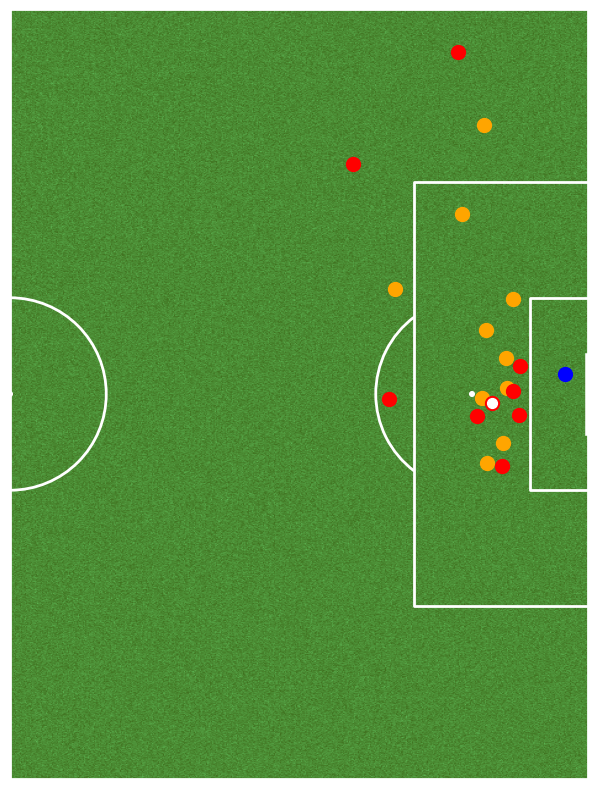

In [171]:
# Create the pitch
mpl_pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = mpl_pitch.draw(figsize=(10, 8))

# Show just the attacking third for better visibility
ax.set_xlim(60, 120)
ax.set_ylim(0, 80)


# Plot the players in the freeze frame
for _, row in freeze_frame_example.iterrows():
    player_x, player_y = row['location_player']
    if row['keeper']:
        ax.scatter(player_x, player_y, color='blue', s=100, label='Keeper')
    elif row['teammate']:
        ax.scatter(player_x, player_y, color='red', s=100, label='Teammate')
    else:
        ax.scatter(player_x, player_y, color='orange', s=100, label='Opponent')

# Plot the ball location (corner kick delivery point)
ball_x, ball_y = freeze_frame_example['location_ball'].values[0]
ax.scatter(ball_x, ball_y, color='white', s=50, label='Ball Location')


# Optionally plot the visible area polygon
# visible_area = freeze_frame_example['visible_area'].values[0]
# if visible_area:
#     polygon = plt.Polygon(visible_area, color='yellow', alpha=0.3, label='Visible Area')
#     ax.add_patch(polygon)

## 6. Headline numbers: conversion vs xG

This is the original Q3 question, narrowed to your subset: what's the conversion rate of corner-resulting headed shots, and how does it compare to StatsBomb's xG estimate for those shots?

Don't overthink this. You're not building an xG model. You're checking whether the existing xG model is well-calibrated for this specific subset, because if it's *not*, that's itself a finding — and it tells you whether "residual = my model could do better" is a sensible target for the actual analysis.

In [172]:
# Compute:
#   - total corner-resulting headed shots in Euro 2024
#   - of those, how many were goals (shot.outcome == "Goal")
#   - observed conversion rate = goals / shots
#   - mean StatsBomb xG across these shots
#   - is there a systematic gap? In which direction?
#
# Tip: with maybe 200-300 corner-headed shots in a single tournament, the conversion
# rate has wide error bars. Compute a binomial 95% CI around your observed rate.
# If the mean xG is inside the CI, you can't claim miscalibration from this data alone.
#
# This is a worked example of why this kind of question needs more than one tournament
# of data to answer well — flag it in your notes for the writeup limitations section.

euro_corner_headers = euro_events_df[(euro_events_df['type'] == 'Shot') & (euro_events_df['shot_body_part'] == 'Head')][
    ['match_id', 'team','player','minute','second','id','type','play_pattern','pass_type','shot_freeze_frame','shot_statsbomb_xg', 'shot_body_part', 'shot_technique','shot_outcome']
    ].sort_values(by=['match_id', 'minute', 'second'])

euro_corner_headers

euro_goals_from_corners = euro_corner_headers[euro_corner_headers['shot_outcome'] == 'Goal']
euro_goals_from_corners

print(f"Total corner-resulting headed shots: {len(euro_corner_headers)}")
print(f"Total goals from corner-headed shots: {len(euro_goals_from_corners)}")
conversion_rate = len(euro_goals_from_corners) / len(euro_corner_headers)
print(f"Observed conversion rate: {conversion_rate:.2%}")  
mean_xg = euro_corner_headers['shot_statsbomb_xg'].mean()
print(f"Mean StatsBomb xG: {mean_xg:.4f}")

Total corner-resulting headed shots: 99
Total goals from corner-headed shots: 6
Observed conversion rate: 6.06%
Mean StatsBomb xG: 0.0818


## 7. What you've learned and where it goes next

Before closing this notebook, write three short paragraphs in the cell below:

1. **What does this data actually contain?** Three sentences max.
2. **What surprised you?** (There should be something. If there isn't, you didn't look hard enough.)
3. **What's the smallest interesting question this data can answer?** This is the seed for notebook 2 and the analysis proper.

Then copy these three paragraphs into `writeup.md` under a `## Data exploration notes` section. The writeup is built as you go, not at the end.

1. This data contains competition, match, event, and frame-level data for the competitions and matches made available by Statsbomb. There's 91 event columns and when joining on the event id, you can see the location of each player in the visible area. The limitation is that the data is not 100% open and that not all 22 players are included in the frame data.
2. This exercise was about learning the data.
3. For corners, this data can answer "how threatening were corners in Euro 2024?" But it can also answer how each team approach corners?